# <a href="https://thetahat.ru/courses/bm-hf-2026-spr">Математическая статистика (ФБМФ, ФМХФ)</a>
## Домашнее задание 2 &mdash; часть A

**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить по ссылке "Сдача ДЗ" на странице курса.
* Дедлайн см. на сайте и в боте. После дедлайна работы не принимаются **вообще никак**, кроме случаев наличия уважительной причины.
* До дедлайна можно поменять решение любое количество раз. Начинайте точно так же сдавать задание, бот подскажет.
* Любую уважительную причину нужно подтвердить документально, отправив скан или фото ассистенту. При этом работу можно сдать позже на столько дней, на сколько время ее действия пересекается с временем выполнения задания.
* Прислать нужно **ноутбук в формате ipynb**. Другие форматы не принимаются.
* Выполнять задание необходимо **полностью самостоятельно**. При обнаружении списывания **все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Простой или основной уровень вы выбираете самостоятельно, выполняя или не выполняя задания типа B. При выборе **простого уровня** достаточно выполнить задания *типа A*. При выборе **основного уровня** нужно выполнять *как задания типа A, так и задания типа B*.
* Для выполнения задания используйте этот ноутбук в качествие основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек. Ячейки с assert'ами **удалять и изменять нельзя**, в противном случае соответствующее задание не будет оценено.
* Комментарии к решению пишите в markdown-ячейках.
* **Если код студента недописан и т.д., то он не оценивается.**
* Каждая задача стоит **5 баллов**.

<font size="5">Данная часть задания проверяется автоматически. Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек. Ячейки с assert'ами <b>удалять и изменять нельзя</b>, в противном случае соответствующее задание *не будет оценено*.</font>


> *Примечание.* Рекомендуется работать с данным ноутбуком **локально** в <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/02_jupyter.html">Jupyter Notebook</a> (например, используя <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/01_anaconda.html#Anaconda">Anaconda</a> или <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/02_jupyter.html#6.-Другие-редакторы">альтернативные варианты</a>). Если вы используете софт по типу Google Colaboratory, то перед отправкой боту данного ноутбука необходимо проверить, что **в ячейках с assert'ами и "# Ваше решение тут"** в метаданных присутствуют поля *metadata* с `nbgrader`. Можно открыть ноутбук с решением в текстовом редакторе (MS Word, Блокнот) и выполнить поиск по документу слова `nbgrader`. Если поиск показал ровно **17 совпадений** &mdash; можете отправлять файл боту. Если совпадений меньше, решение может быть не оценено. В таком случае попробуйте скачать файл в форме `ipynb` еще раз и перенесите решения в новый файл. **Внимание! Сайт не проверяет решение и не проверяет наличие метаданных.** 

In [1]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
%matplotlib inline

## Задачи типа A (достаточно на "хор")

---

### Задача 1

Пусть $X_1, ..., X_n$&mdash; выборка пуассоновского распределения $Pois(\theta)$, то есть $\mathsf{P}(X_i = k) = \frac{\theta^k}{k!} e^{-\theta}$ при $k \in \{0, 1, 2, ...\}$.

Реализуйте функции, вычисляющие:
* Асимптотически нормальную оценку $\theta$;
* Оценку асимптотической дисперсии данной оценки.
* Асимптотический доверительный интервал на $\theta$.

In [2]:
def poiss_asymp_norm_est(x):
    x = np.asarray(x)
    est = np.mean(x)
    return est

In [3]:
x = np.array([1, 5, 5, 3, 2, 4, 2, 8, 4, 6])
assert np.allclose(poiss_asymp_norm_est(x), 4, atol=1e-2)

In [4]:
def poiss_asymp_var_est(x):
    x = np.asarray(x)
    est = np.mean(x)
    return est

In [6]:
x = np.array([1, 5, 5, 3, 2, 4, 2, 8, 4, 6])
assert np.allclose(poiss_asymp_var_est(x), 4, atol=1e-2)

In [7]:
def poiss_asymp_confint(x, confidence_level=0.95):
    x = np.asarray(x)
    n = len(x)

    theta_hat = poiss_asymp_norm_est(x)
    var_hat = poiss_asymp_var_est(x)

    alpha = 1 - confidence_level
    z = sps.norm.ppf(1 - alpha / 2)

    margin = z * np.sqrt(var_hat / n)

    l = theta_hat - margin
    r = theta_hat + margin

    return l, r

In [8]:
x = np.array([1, 5, 5, 3, 2, 4, 2, 8, 4, 6])
assert np.allclose(poiss_asymp_confint(x), [2.76, 5.24], atol=1e-2)

Проверим, что при большом размере выборки получившийся интервал действительно имеет уровень доверия $\approx 0.95$:

In [9]:
np.random.seed(0)
dist = sps.poisson(5)
l, r = np.stack([
    poiss_asymp_confint(dist.rvs(size=(500,)))
    for _ in range(10_000)
], axis=1)
estimated_conf_level = np.mean((l <= 5) & (5 <= r))
assert 0.94 <= estimated_conf_level <= 0.96, f"Неправильный уровень доверия {estimated_conf_level:.4f}"

-----

### Задача 2
Дана выборка $X_1, ..., X_n$ из распределения Лапласа с плотностью $p(x) = \frac{1}{2} e^{-|x-\theta|}$. Реализуйте функцию, вычисляющую асимптотический доверительный интервал для параметра $\theta$.

In [12]:
def laplace_asymp_confint(x, confidence_level=0.95):

    x = np.asarray(x)
    n = len(x)

    theta_hat = np.median(x)

    alpha = 1 - confidence_level
    z = sps.norm.ppf(1 - alpha / 2)

    margin = z / np.sqrt(n)

    l = theta_hat - margin
    r = theta_hat + margin

    return l, r

In [13]:
np.random.seed(0)
dist = sps.laplace(loc=2)
l, r = np.stack([
    laplace_asymp_confint(dist.rvs(size=(500,)))
    for _ in range(10_000)
], axis=1)
estimated_conf_level = np.mean((l <= 2) & (2 <= r))
assert 0.94 <= estimated_conf_level <= 0.96, f"Неправильный уровень доверия {estimated_conf_level:.4f}"

---

### Задача 3
В этой задаче нужно визуализировать *свойство асимптотической нормальности*. Посмотрите также на <a href="https://thetahat.ru/courses/ad/main/9/2_lln">этот ноутбук</a>.

*a).* Пусть $X_1, ..., X_n$&mdash; выборка из распределения $U(0, 1)$. Согласно центральной предельной теореме оценка $\widehat{\theta} = 2\overline{X}$ является асимптотически нормальной оценкой параметра $\theta$.  Вам нужно убедиться в этом, сгенерировав множество наборов случайных величин и посчитав по каждому из наборов величину $Z_n = \sqrt{n} \left( 2\overline{X} - \theta \right)$ в зависимости от размера набора. 

<a href="https://thetahat.ru/courses/python/05">Сгенерируйте</a> множество выборок $X^1, \dots, X^{300}$ из распределения $U[0, 1]$:  $\; X^j = (X^j_1, \dots, X^j_{500}), 1 \leq j \leq 300$.<br> 
По каждой из них <a href="https://thetahat.ru/courses/python/03">посчитайте</a> оценки  $\widehat{\theta}_{jn} = 2\frac{X^j_1 + \dots + X^j_n}{n}$ для $1 \leq n \leq 500$,  то есть оценку параметра $\theta$ по первым $n$ наблюдениям $j$-й выборки.
Для этих оценок посчитайте статистики $Z_{jn} = \sqrt{n} \left( \widehat{\theta}_{jn} - \theta \right)$, где $\theta = 1$.

In [24]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

In [31]:
np.random.seed(0) # Менялся на 1, 2, 42 для проверки гистограммы

n = 500
num_samples = 300

# Генерируем 300 выборок размера 500
# Каждая строка — отдельная выборка
x = sps.uniform(loc=0, scale=1).rvs(size=(num_samples, n))

# Номера наблюдений: 1, 2, ..., 500
ns = np.arange(1, n + 1)

# Считаем накопительные суммы по каждой строке
# cumsum[:, k] содержит сумму первых k + 1 элементов в каждой выборке
cumsum = np.cumsum(x, axis=1)

# Считаем оценки theta_hat_jn = 2 * среднее первых n наблюдений
estimation = 2 * cumsum / ns

# Считаем статистики Z_jn = sqrt(n) * (theta_hat_jn - theta)
# Здесь theta = 1
z = np.sqrt(ns) * (estimation - 1)

In [32]:
assert x.shape == estimation.shape == z.shape == (300, 500)
assert ((0 <= x) & (x <= 1)).all()
assert np.allclose(((1/3 <= x) & (x <= 2/3)).mean(), 1/3, atol=1e-2)
assert np.allclose(estimation[1, 2], 2 * (x[1, 0] + x[1, 1] + x[1, 2]) / 3)
assert np.allclose(z[1, 2], 3**0.5 * estimation[1, 2] - 3**0.5)

Для каждого $j$ нанесите на один график зависимость $Z_{jn}$ от $n$ <a href="https://thetahat.ru/courses/python/04">с помощью `plt.plot`</a>. Каждая кривая должна быть нарисована *одним цветом* с прозрачностью `alpha=0.05`. Сходятся ли значения $Z_{jn}$ к какой-либо константе?

In [33]:
def plot_trajectories(z):
    """
    Строит траектории Z_jn для всех выборок j.

    Каждая строка массива z — это одна траектория:
    Z_j1, Z_j2, ..., Z_j500.
    """
    ns = np.arange(1, z.shape[1] + 1)

    plt.figure(figsize=(10, 6))

    for j in range(z.shape[0]):
        plt.plot(ns, z[j], color="C0", alpha=0.05)

    plt.xlabel("n")
    plt.ylabel(r"$Z_{jn}$")
    plt.title(r"Траектории $Z_{jn}$")
    plt.grid()

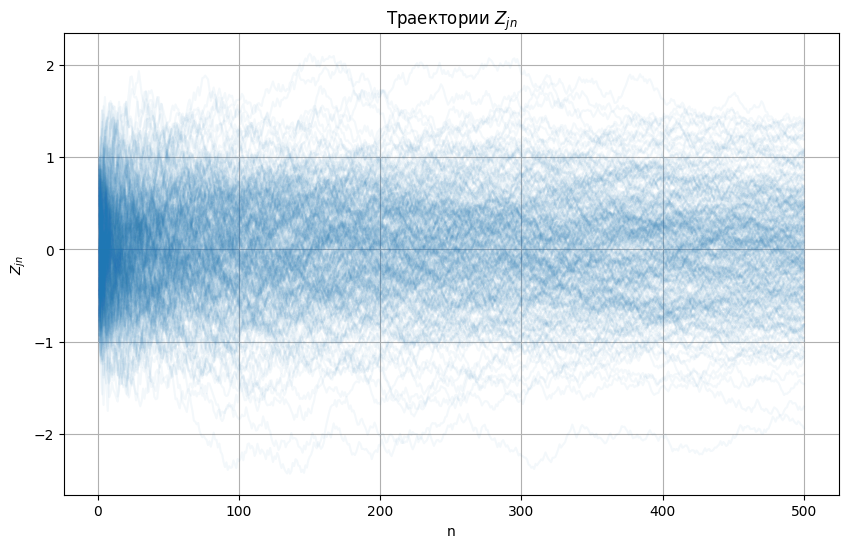

In [34]:
plot_trajectories(z)
lines = plt.gca().lines
assert len(lines) == z.shape[0], "Неверное к-во линий. Не вызывайте plt.show()!"
assert np.allclose(lines[42].get_ydata(), z[42]), "Неверные координаты линий"
assert lines[42].get_alpha() == 0.05, "Неправильная прозрачность линий"
assert len(set(line.get_color() for line in lines)) == 1, "Цвета должны быть одинаковыми"

Для $n=500$ по выборке $Z_{1,500}, \dots, Z_{300,500}$ постройте  [гистограмму и график плотности](https://thetahat.ru/courses/ad/main/9/1_bus_waiting_time) распределения $\mathcal{N}(0, \sigma^2)$, где $\sigma^2$ — асимптотическая дисперсия.  
Не забудьте сделать легенду.

In [35]:
def plot_distribution(z):
    """
    Строит нормированную гистограмму значений Z_jn при максимальном n
    и график плотности предельного нормального распределения.

    Для оценки theta = 2 * mean(X), где X ~ U(0, 1),
    асимптотическая дисперсия равна 1/3.
    """
    values = z[:, -1]

    asymp_var = 1 / 3
    asymp_std = np.sqrt(asymp_var)

    grid = np.linspace(values.min() - 1, values.max() + 1, 300)
    density = sps.norm(loc=0, scale=asymp_std).pdf(grid)

    plt.figure(figsize=(10, 6))

    plt.hist(
        values,
        bins=20,
        density=True,
        alpha=0.6,
        label=r"Гистограмма $Z_{j,500}$"
    )

    plt.plot(
        grid,
        density,
        label=r"Плотность $\mathcal{N}(0, 1/3)$"
    )

    plt.xlabel(r"$Z_{j,500}$")
    plt.ylabel("Плотность")
    plt.title(r"Распределение $Z_{j,500}$")
    plt.legend()
    plt.grid()

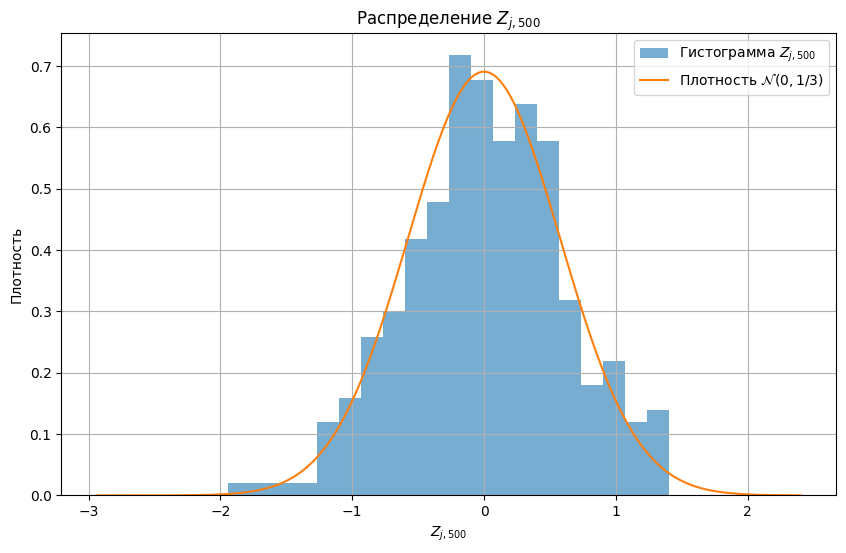

In [36]:
plot_distribution(z)
axes = plt.gca()
total_hist_area = sum(hist_rect.get_width() * hist_rect.get_height()
                      for hist_rect in axes.patches)
assert np.allclose(total_hist_area, 1.0, atol=1e-1), "Гистограмма должна быть нормированна"
assert len(axes.lines) == 1, "Нет графика плотности"
pdf = axes.lines[0]
pdf_fragment = pdf.get_ydata()[np.abs(pdf.get_xdata()) <= 0.3]
assert len(pdf_fragment) > 0, "Некорректный график плотности"
assert ((0.6 <= pdf_fragment) & (pdf_fragment <= 0.7)).all(), "Некорректный график плотности"
assert axes.get_legend() is not None, "Нет легенды"
assert len(axes.get_legend_handles_labels()[1]) == 2, "Не все графики подписаны"

Сделайте вывод о смысле свойства асимптотической нормальности. Подтверждают ли сделанные эксперименты теоретические свойства?

**Вывод:** 
Мы наблюдаем, что при достаточно большом размере выборки наша теория корректно описывает условно эксперментальные данные (см гистограмму), при разных seed'ах данные в среденем ложились как нормлаьное распределение, а знать какая будет ошибка полезно
ВАЖНО ошибка не стремится к нулю, а просто старновится нормально распереленно, его средний всегда 0, а вот сигма ~ sqrt(1/3n), то есть ее можно усеньшить увеличивая выборку, но она все равно будет!!!

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для Статистики ФБМФ и ФЭФМ